<h1><b> Librerías

In [9]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler          # ← AMP para entrenamiento más rápido en GPU
from torchvision import models, transforms

# Sklearn
from sklearn.model_selection import StratifiedKFold  # ← necesario para el KFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score
)

# Utilidades
from tqdm import tqdm

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Verificación GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Usando dispositivo:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM disponible:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")

PyTorch version: 2.14.0.dev20260621+cu132
Usando dispositivo: cuda
GPU: NVIDIA GeForce RTX 5060
VRAM disponible: 8.55 GB


<H1><b> Configuración global

In [10]:
# Rutas sinteticas
FOLDERS_SPLIT = {
    "train": "sinteticas2/syn_spect_train",
    "valid": "sinteticas2/syn_spect_valid",
    "test":  "sinteticas2/syn_spect_test"
}
CSV_PATH   = "MDS-UPDRS.csv"
MODEL_SAVE = "model2_kfold_mbrs_sin_severos/"
os.makedirs(MODEL_SAVE, exist_ok=True)

# Imagen
HEIGHT, WIDTH        = 256, 256
LOW_FRAME, TOP_FRAME = 82, 94

# Entrenamiento
BATCH_SIZE  = 16
NUM_CLASES  = 2
EPOCHS      = 20
LR          = 1e-4
PATIENCE    = 7
N_FOLDS     = 5  # 5-fold → cada fold valida ~20% del pool
NUM_WORKERS = 0

# Arquitectura
ARQUITECTURA = "MobileNet"  # opciones: MobileNet - ResNet50 - Vgg16

# Etiquetas
TARGET_NAMES = ["leve", "moderado"]

# Función de clase MBRS
def clase_pd(m):
    if pd.isna(m): return -1
    if m <= 5:      return 1
    if 6 <= m <= 12: return 2
    return -1

print("Configuración:")
print(f"  Dispositivo  : {DEVICE}")
print(f"  Imagen       : {HEIGHT}x{WIDTH}")
print(f"  Slices       : {LOW_FRAME} al {TOP_FRAME}  ({TOP_FRAME - LOW_FRAME - 1} slices por volumen)")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Épocas       : {EPOCHS}")
print(f"  Paciencia    : {PATIENCE}")
print(f"  Folds        : {N_FOLDS}")
print(f"  Clases       : {NUM_CLASES}  {TARGET_NAMES}")
print(f"  LR           : {LR}")
print(f"  Arquitectura : {ARQUITECTURA}")

Configuración:
  Dispositivo  : cuda
  Imagen       : 256x256
  Slices       : 82 al 94  (11 slices por volumen)
  Batch size   : 16
  Épocas       : 20
  Paciencia    : 7
  Folds        : 5
  Clases       : 2  ['leve', 'moderado']
  LR           : 0.0001
  Arquitectura : MobileNet


<h1><b> Splits

In [11]:
# Test fijo — nunca se toca durante KFold
TEST_IDS = {
    "3386", "3552", "3554", "3559", "3565", "3575", "3591", "3593",
    "3759", "3765", "3767", "3769", "3806", "3807", "3824", "3832",
    "3857", "3863"
}

print(f"Test fijo : {len(TEST_IDS)} sujetos")
print(f"El pool restante se divide en {N_FOLDS} folds automáticamente")

Test fijo : 18 sujetos
El pool restante se divide en 5 folds automáticamente


<h1><b> DataFrames

In [12]:
def build_dataframes(folders_split):

    # Cargar CSV y asignar clase MBRS
    csv_df = pd.read_csv(CSV_PATH)
    csv_df["label_idx"] = csv_df["MBRS"].apply(clase_pd)
    # Solo clases válidas (1, 2, 3)
    csv_df = csv_df[csv_df["label_idx"] > 0]
    csv_df["PATNO"] = csv_df["PATNO"].astype(str)
    mbrs_map = dict(zip(csv_df["PATNO"], csv_df["label_idx"]))

    records = []

    for split_name, split_folder in folders_split.items():
        if not os.path.exists(split_folder):
            print(f"  ADVERTENCIA: no existe la carpeta {split_folder}")
            continue

        nii_files = [f for f in sorted(os.listdir(split_folder)) if f.endswith(".nii.gz")]
        print(f"  [{split_name.upper()}] Encontrados {len(nii_files)} archivos válidos (.nii.gz) en '{split_folder}'")

        for fname in nii_files:
            tokens           = fname.split("_")
            case_number      = tokens[0]
            file_label_token = tokens[1].upper()

            # Solo sujetos AD (parkinson) — leve/moderado no aplica a controles
            if file_label_token != "AD":
                continue

            if case_number not in mbrs_map:
                # No tiene MBRS en el CSV — se excluye
                continue

            label_idx = mbrs_map[case_number]  # 1 o 2
            label_idx_0 = label_idx - 1        # 0, 1

            records.append({
                "path":        os.path.join(split_folder, fname),
                "label":       TARGET_NAMES[label_idx_0],
                "label_idx":   label_idx_0,
                "case_number": case_number,
            })

    df = pd.DataFrame(records)

    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    test_df = df[df["case_number"].isin(TEST_IDS)].reset_index(drop=True)
    pool_df = df[~df["case_number"].isin(TEST_IDS)].reset_index(drop=True)

    return pool_df, test_df


pool_df, test_df = build_dataframes(FOLDERS_SPLIT)

print("\n" + "="*40)
print("DISTRIBUCIÓN DE VOLÚMENES")
print("="*40)
for name, df in [("Pool (KFold)", pool_df), ("Test", test_df)]:
    print(f"\n{name} — Total: {len(df)} volúmenes")
    if not df.empty:
        print(df.groupby("label")["path"].count().to_string())
    else:
        print("  (Sin datos cargados)")

if not test_df.empty:
    faltantes = TEST_IDS - set(test_df["case_number"])
    if faltantes:
        print(f"\nIDs no encontrados en disco: {faltantes}")

  [TRAIN] Encontrados 148 archivos válidos (.nii.gz) en 'sinteticas2/syn_spect_train'
  [VALID] Encontrados 18 archivos válidos (.nii.gz) en 'sinteticas2/syn_spect_valid'
  [TEST] Encontrados 18 archivos válidos (.nii.gz) en 'sinteticas2/syn_spect_test'

DISTRIBUCIÓN DE VOLÚMENES

Pool (KFold) — Total: 87 volúmenes
label
leve        34
moderado    53

Test — Total: 7 volúmenes
label
leve        3
moderado    4

IDs no encontrados en disco: {'3807', '3575', '3565', '3806', '3759', '3769', '3857', '3554', '3765', '3767', '3552'}


<h1><b> Dataset y DataLoader

In [14]:
class SPECTDataset(Dataset):

    def __init__(self, df, transform=None):
        self.transform = transform
        self.samples   = []  # lista de (path, label_idx, case_number, slice_idx)

        for _, row in df.iterrows():
            vol = nib.load(row["path"]).get_fdata()

            # El volumen puede ser (X, Y, Z) — los slices axiales van en el eje 2
            num_slices = vol.shape[2]

            for s in range(LOW_FRAME, min(TOP_FRAME, num_slices)):
                self.samples.append((
                    row["path"],
                    row["label_idx"],
                    row["case_number"],
                    s
                ))

        print(f"  Dataset listo: {len(self.samples)} slices")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, case_number, slice_idx = self.samples[idx]

        # Cargar volumen y extraer slice axial
        vol   = nib.load(path).get_fdata()
        slice_2d = vol[:, :, slice_idx].astype(np.float32)

        # Normalizar a [0, 1]
        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_2d = (slice_2d - s_min) / (s_max - s_min)

        # Redimensionar a HEIGHT x WIDTH
        slice_img = plt.cm.gray(slice_2d)[:, :, :3]          # H x W x 3  float64
        slice_img = (slice_img * 255).astype(np.uint8)

        from PIL import Image
        img = Image.fromarray(slice_img).resize((WIDTH, HEIGHT))

        if self.transform:
            img = self.transform(img)

        return img, label, case_number


# Transformaciones
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),               # ← augmentation ligero para datos escasos
    transforms.ToTensor(),                          # [0,1], shape (3, H, W)
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Solo test se pre-construye — train/val los crea KFold en cada fold
test_dataset = SPECTDataset(test_df, transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Test slices : {len(test_dataset)}")

  Dataset listo: 84 slices
Test slices : 84


<h1><b> Modelo de entrenamiento

In [15]:
def make_model(arquitectura, num_clases):

    if arquitectura == "MobileNet":
        base_model = models.mobilenet_v2(weights="IMAGENET1K_V1")
        # Congelar las primeras capas
        for i, param in enumerate(base_model.parameters()):
            if i < 70:
                param.requires_grad = False
        # Reemplazar cabeza
        in_features = base_model.classifier[1].in_features
        base_model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_clases)
        )

    elif arquitectura == "ResNet50":
        base_model = models.resnet50(weights="IMAGENET1K_V1")
        for i, param in enumerate(base_model.parameters()):
            if i < 100:
                param.requires_grad = False
        in_features = base_model.fc.in_features
        base_model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_clases)
        )

    elif arquitectura == "Vgg16":
        base_model = models.vgg16(weights="IMAGENET1K_V1")
        for i, param in enumerate(base_model.parameters()):
            if i < 10:
                param.requires_grad = False
        in_features = base_model.classifier[6].in_features
        base_model.classifier[6] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_clases)
        )

    else:
        raise ValueError(f"Arquitectura no soportada: {arquitectura}")

    model = base_model.to(DEVICE)

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parámetros totales    : {total_params:,}")
    print(f"  Parámetros entrenables: {trainable_params:,}")

    return model

# Instanciar
# model = make_model(ARQUITECTURA, NUM_CLASES)

<h1><b> Entrenamiento

In [16]:
def train_model(model, train_loader, val_loader, fold_idx):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )

    best_val_acc  = 0.0
    epochs_no_imp = 0
    history       = {"train_loss": [], "train_acc": [],
                     "val_loss":   [], "val_acc":   []}
    best_path     = os.path.join(MODEL_SAVE, f"{ARQUITECTURA}_fold{fold_idx}.pth")

    for epoch in range(EPOCHS):

        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for imgs, labels, _ in tqdm(train_loader, desc=f"Fold {fold_idx} Epoch {epoch+1}/{EPOCHS}"):
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item() * imgs.size(0)
            preds          = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total   += imgs.size(0)

        train_loss /= train_total
        train_acc   = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs   = imgs.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs     = model(imgs)
                loss        = criterion(outputs, labels)
                val_loss   += loss.item() * imgs.size(0)
                preds       = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += imgs.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  Epoch {epoch+1:02d} | "
              f"train_loss: {train_loss:.4f}  train_acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            epochs_no_imp = 0
            torch.save(model.state_dict(), best_path)
            print(f"  ✓ Fold {fold_idx} mejor modelo guardado (val_acc: {best_val_acc:.4f})")
        else:
            epochs_no_imp += 1
            print(f"  Sin mejora ({epochs_no_imp}/{PATIENCE})")
            if epochs_no_imp >= PATIENCE:
                print(f"  EarlyStopping fold {fold_idx}.")
                break

    return model, history, best_val_acc, best_path

In [17]:
skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []  # guarda (fold_idx, best_val_acc, best_path)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(pool_df, pool_df["label_idx"]), start=1):

    print(f"\n{'='*50}")
    print(f"  FOLD {fold_idx}/{N_FOLDS}")
    print(f"{'='*50}")

    train_fold_df = pool_df.iloc[train_idx].reset_index(drop=True)
    val_fold_df   = pool_df.iloc[val_idx].reset_index(drop=True)

    train_dataset = SPECTDataset(train_fold_df, transform=train_transform)
    val_dataset   = SPECTDataset(val_fold_df,   transform=val_test_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model = make_model(ARQUITECTURA, NUM_CLASES)

    model, history, best_val_acc, best_path = train_model(model, train_loader, val_loader, fold_idx)

    fold_results.append((fold_idx, best_val_acc, best_path))
    print(f"  Fold {fold_idx} terminado — mejor val_acc: {best_val_acc:.4f}")

# Resumen de folds
print(f"\n{'='*50}")
print("RESUMEN KFOLD")
print(f"{'='*50}")
for fold_idx, acc, path in fold_results:
    print(f"  Fold {fold_idx} | val_acc: {acc:.4f} | {path}")

# Mejor fold
best_fold = max(fold_results, key=lambda x: x[1])
print(f"\n  Mejor fold: {best_fold[0]} con val_acc: {best_fold[1]:.4f}")
print(f"  Pesos: {best_fold[2]}")


  FOLD 1/5
  Dataset listo: 828 slices
  Dataset listo: 216 slices
  Parámetros totales    : 4,061,442
  Parámetros entrenables: 3,930,754


Fold 1 Epoch 1/20: 100%|██████████| 52/52 [02:59<00:00,  3.45s/it]


  Epoch 01 | train_loss: 0.6516  train_acc: 0.6196 | val_loss: 0.7266  val_acc: 0.5602
  ✓ Fold 1 mejor modelo guardado (val_acc: 0.5602)


Fold 1 Epoch 2/20: 100%|██████████| 52/52 [02:58<00:00,  3.44s/it]


  Epoch 02 | train_loss: 0.4934  train_acc: 0.7645 | val_loss: 1.2804  val_acc: 0.2500
  Sin mejora (1/7)


...

  Epoch 08 | train_loss: 0.0774  train_acc: 0.9702 | val_loss: 2.0257  val_acc: 0.5049
  Sin mejora (5/7)


Fold 5 Epoch 9/20: 100%|██████████| 53/53 [02:56<00:00,  3.33s/it]


  Epoch 09 | train_loss: 0.0959  train_acc: 0.9667 | val_loss: 2.3700  val_acc: 0.4608
  Sin mejora (6/7)


Fold 5 Epoch 10/20: 100%|██████████| 53/53 [03:04<00:00,  3.49s/it]


  Epoch 10 | train_loss: 0.0556  train_acc: 0.9845 | val_loss: 2.5122  val_acc: 0.4804
  Sin mejora (7/7)
  EarlyStopping fold 5.
  Fold 5 terminado — mejor val_acc: 0.6176

RESUMEN KFOLD
  Fold 1 | val_acc: 0.5602 | model2_kfold_mbrs_sin_severos/MobileNet_fold1.pth
  Fold 2 | val_acc: 0.6111 | model2_kfold_mbrs_sin_severos/MobileNet_fold2.pth
  Fold 3 | val_acc: 0.5588 | model2_kfold_mbrs_sin_severos/MobileNet_fold3.pth
  Fold 4 | val_acc: 0.6667 | model2_kfold_mbrs_sin_severos/MobileNet_fold4.pth
  Fold 5 | val_acc: 0.6176 | model2_kfold_mbrs_sin_severos/MobileNet_fold5.pth

  Mejor fold: 4 con val_acc: 0.6667
  Pesos: model2_kfold_mbrs_sin_severos/MobileNet_fold4.pth


<h1><b>Evaluación por sujeto

  Parámetros totales    : 4,061,442
  Parámetros entrenables: 3,930,754

##################################################
  FOLD 1 — MobileNet_fold1.pth
##################################################


Fold 1: 100%|██████████| 6/6 [00:18<00:00,  3.02s/it]



  Slice:
    AUC                 : 0.8142
    Balanced Accuracy   : 0.6458
    Recall              : 0.9583
    Specificity         : 0.3333
    F1-Score            : 0.7797

  Sujeto:
    AUC                 : 0.9167
    Balanced Accuracy   : 0.6667
    Recall              : 1.0000
    Specificity         : 0.3333
    F1-Score            : 0.8000


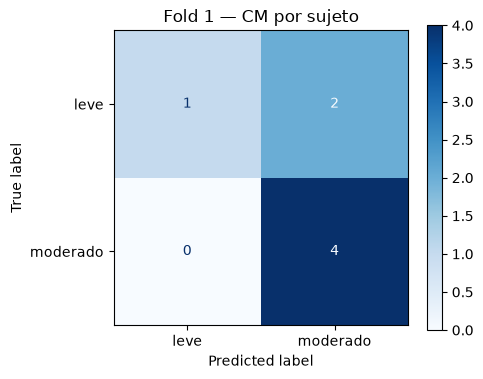


##################################################
  FOLD 2 — MobileNet_fold2.pth
##################################################


Fold 2: 100%|██████████| 6/6 [00:18<00:00,  3.04s/it]



  Slice:
    AUC                 : 0.7014
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.7273

  Sujeto:
    AUC                 : 0.8333
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.7273


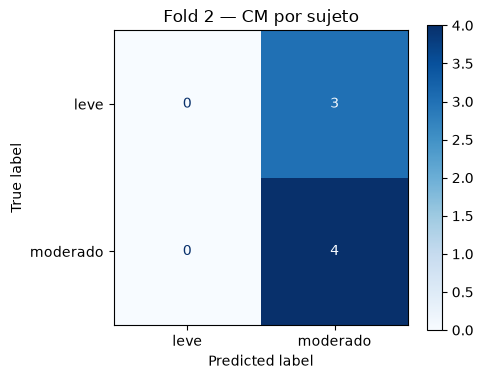


##################################################
  FOLD 3 — MobileNet_fold3.pth
##################################################


Fold 3: 100%|██████████| 6/6 [00:18<00:00,  3.05s/it]



  Slice:
    AUC                 : 0.7546
    Balanced Accuracy   : 0.6250
    Recall              : 1.0000
    Specificity         : 0.2500
    F1-Score            : 0.7805

  Sujeto:
    AUC                 : 0.9167
    Balanced Accuracy   : 0.6667
    Recall              : 1.0000
    Specificity         : 0.3333
    F1-Score            : 0.8000


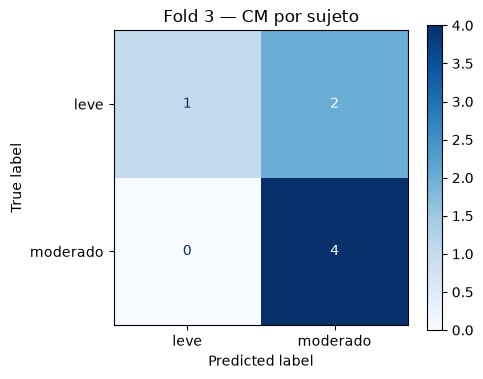


##################################################
  FOLD 4 — MobileNet_fold4.pth
##################################################


Fold 4: 100%|██████████| 6/6 [00:18<00:00,  3.12s/it]



  Slice:
    AUC                 : 0.6155
    Balanced Accuracy   : 0.6250
    Recall              : 0.9167
    Specificity         : 0.3333
    F1-Score            : 0.7586

  Sujeto:
    AUC                 : 0.5000
    Balanced Accuracy   : 0.6667
    Recall              : 1.0000
    Specificity         : 0.3333
    F1-Score            : 0.8000


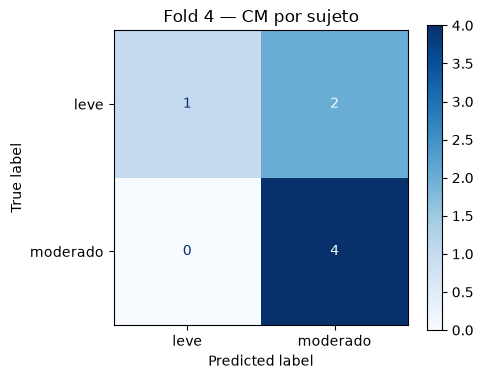


##################################################
  FOLD 5 — MobileNet_fold5.pth
##################################################


Fold 5: 100%|██████████| 6/6 [00:18<00:00,  3.02s/it]



  Slice:
    AUC                 : 0.6823
    Balanced Accuracy   : 0.6042
    Recall              : 0.8750
    Specificity         : 0.3333
    F1-Score            : 0.7368

  Sujeto:
    AUC                 : 0.8333
    Balanced Accuracy   : 0.6667
    Recall              : 1.0000
    Specificity         : 0.3333
    F1-Score            : 0.8000


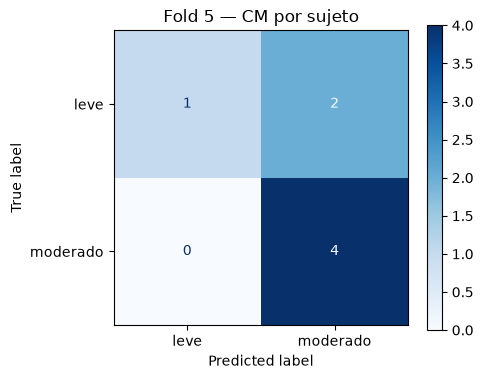


  RESUMEN GLOBAL K-FOLD

  Slice:
    AUC                 : 0.7136 ± 0.0672
    Balanced Accuracy   : 0.6000 ± 0.0517
    Recall              : 0.9500 ± 0.0486
    Specificity         : 0.2500 ± 0.1291
    F1-Score            : 0.7566 ± 0.0217

  Sujeto:
    AUC                 : 0.8000 ± 0.1546
    Balanced Accuracy   : 0.6333 ± 0.0667
    Recall              : 1.0000 ± 0.0000
    Specificity         : 0.2667 ± 0.1333
    F1-Score            : 0.7855 ± 0.0291


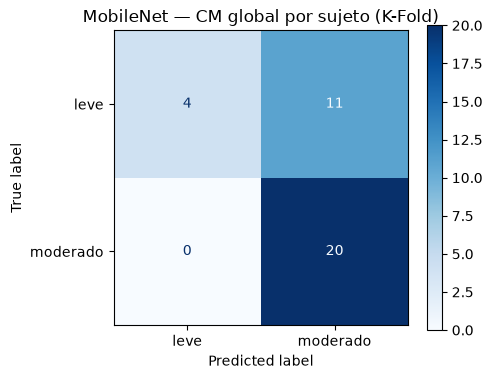


Resumen guardado en: model2_kfold_mbrs_sin_severos/kfold_resumen_global.txt
Probabilidades guardadas en: model2_kfold_mbrs_sin_severos/kfold_probabilidades.csv


In [20]:
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import glob

def get_metrics_kfold(model, loader_fn, weights_dir, k=5):
    """
    loader_fn: función que recibe el fold y retorna el test_loader de ese fold
               si usas el mismo loader para todos, pasa lambda fold: test_loader
    weights_dir: carpeta con los 5 .pth, se ordenan alfabéticamente
    """

    weights_list = sorted(glob.glob(os.path.join(weights_dir, "*.pth")))
    assert len(weights_list) == k, f"Se esperaban {k} pesos, se encontraron {len(weights_list)}"

    all_fold_slice  = []
    all_fold_subj   = []

    # Para confusion matrix global por sujeto
    all_subj_labels_global = []
    all_subj_preds_global  = []

    # Para CSV global de probabilidades
    all_probs_rows = []

    for fold_idx, weights_path in enumerate(weights_list):
        print(f"\n{'#'*50}")
        print(f"  FOLD {fold_idx + 1} — {os.path.basename(weights_path)}")
        print(f"{'#'*50}")

        loader = loader_fn(fold_idx)

        model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
        model.eval()

        all_labels, all_preds, all_probs = [], [], []
        subject_data = {}

        with torch.no_grad():
            for imgs, labels, case_numbers in tqdm(loader, desc=f"Fold {fold_idx+1}"):
                imgs = imgs.to(DEVICE)
                outputs = model(imgs)
                probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                preds = outputs.argmax(dim=1).cpu().numpy()
                labels_np = labels.numpy()

                all_labels.extend(labels_np)
                all_preds.extend(preds)
                all_probs.extend(probs)

                for case, pred, prob, label in zip(case_numbers, preds, probs, labels_np):
                    if case not in subject_data:
                        subject_data[case] = {"label": int(label), "preds": [], "probs": []}
                    subject_data[case]["preds"].append(int(pred))
                    subject_data[case]["probs"].append(float(prob))

        subj_labels, subj_preds, subj_probs, subj_cases = [], [], [], []
        for case, d in sorted(subject_data.items()):
            subj_labels.append(d["label"])
            subj_preds.append(1 if sum(d["preds"]) >= len(d["preds"]) / 2 else 0)
            subj_probs.append(sum(d["probs"]) / len(d["probs"]))
            subj_cases.append(case)

        all_subj_labels_global.extend(subj_labels)
        all_subj_preds_global.extend(subj_preds)

        # Guardar filas para el CSV global (id paciente + probabilidad + fold)
        for case, prob, label, pred in zip(subj_cases, subj_probs, subj_labels, subj_preds):
            all_probs_rows.append({
                "fold":        fold_idx + 1,
                "case_number": case,
                "label_true":  TARGET_NAMES[label],
                "label_pred":  TARGET_NAMES[pred],
                "probabilidad": prob
            })

        def compute(y_true, y_pred, y_prob):
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            return {
                "AUC":               roc_auc_score(y_true, y_prob),
                "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Recall":            recall_score(y_true, y_pred),
                "Specificity":       tn / (tn + fp),
                "F1-Score":          f1_score(y_true, y_pred),
            }

        slice_m = compute(all_labels, all_preds, all_probs)
        subj_m  = compute(subj_labels, subj_preds, subj_probs)

        for name, m in [("Slice", slice_m), ("Sujeto", subj_m)]:
            print(f"\n  {name}:")
            for k_name, v in m.items():
                print(f"    {k_name:20s}: {v:.4f}")

        all_fold_slice.append(slice_m)
        all_fold_subj.append(subj_m)

        # Confusion matrix por sujeto de este fold
        cm = confusion_matrix(subj_labels, subj_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(cmap=plt.cm.Blues, values_format="d", ax=ax)
        ax.set_title(f"Fold {fold_idx+1} — CM por sujeto")
        plt.tight_layout()
        plt.savefig(os.path.join(weights_dir, f"fold{fold_idx+1}_cm_sujeto.png"), dpi=150)
        plt.show()

    # ── Resumen global ──────────────────────────────────────────────
    print(f"\n{'='*50}")
    print("  RESUMEN GLOBAL K-FOLD")
    print(f"{'='*50}")

    for nivel, fold_metrics in [("Slice", all_fold_slice), ("Sujeto", all_fold_subj)]:
        print(f"\n  {nivel}:")
        keys = list(fold_metrics[0].keys())
        for k_name in keys:
            vals = [m[k_name] for m in fold_metrics]
            print(f"    {k_name:20s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    # Confusion matrix global por sujeto (todos los folds)
    cm_global = confusion_matrix(all_subj_labels_global, all_subj_preds_global)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_global, display_labels=TARGET_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap=plt.cm.Blues, values_format="d", ax=ax)
    ax.set_title(f"{ARQUITECTURA} — CM global por sujeto (K-Fold)")
    plt.tight_layout()
    plt.savefig(os.path.join(weights_dir, "kfold_cm_sujeto_global.png"), dpi=150)
    plt.show()

    # Guardar resumen global en txt
    txt_path = os.path.join(weights_dir, "kfold_resumen_global.txt")
    with open(txt_path, "w") as f:
        f.write(f"RESUMEN GLOBAL K-FOLD — {ARQUITECTURA}\n")
        f.write("="*50 + "\n")
        for nivel, fold_metrics in [("Slice", all_fold_slice), ("Sujeto", all_fold_subj)]:
            f.write(f"\n{nivel}:\n")
            keys = list(fold_metrics[0].keys())
            for k_name in keys:
                vals = [m[k_name] for m in fold_metrics]
                f.write(f"  {k_name:20s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}\n")
        f.write("\nMétricas por fold (Sujeto):\n")
        for i, m in enumerate(all_fold_subj):
            f.write(f"\n  Fold {i+1}:\n")
            for k_name, v in m.items():
                f.write(f"    {k_name:20s}: {v:.4f}\n")
    print(f"\nResumen guardado en: {txt_path}")

    # Guardar CSV de probabilidades (id paciente + probabilidad, por fold)
    probs_df = pd.DataFrame(all_probs_rows)
    csv_path = os.path.join(weights_dir, "kfold_probabilidades.csv")
    probs_df.to_csv(csv_path, index=False)
    print(f"Probabilidades guardadas en: {csv_path}")

    return all_fold_slice, all_fold_subj


model = make_model(ARQUITECTURA, NUM_CLASES)

# --- USO ---
WEIGHTS_DIR = MODEL_SAVE

# Si usas el mismo loader para todos los folds:
slice_metrics, subj_metrics = get_metrics_kfold(
    model,
    loader_fn=lambda fold: test_loader,
    weights_dir=WEIGHTS_DIR
)

# **Evaluación individual y boxplot**

In [21]:
from collections import defaultdict
from scipy import stats

In [22]:
print(f"Pacientes en test_df: {test_df['case_number'].nunique()}")
print(test_df['case_number'].unique())

Pacientes en test_df: 7
<StringArray>
['3386', '3559', '3591', '3593', '3824', '3832', '3863']
Length: 7, dtype: str


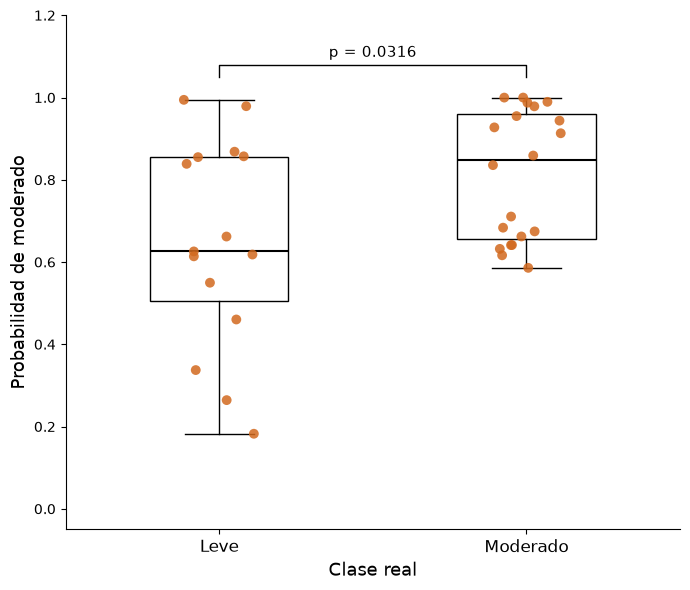


Mann-Whitney p-value: 0.0316
  Leve       | n=15 | μ=0.647 | σ²=0.0606
  Moderado   | n=20 | μ=0.812 | σ²=0.0236


In [24]:
prob_df = pd.read_csv(os.path.join(MODEL_SAVE, "kfold_probabilidades.csv"))
prob_df["case_number"] = prob_df["case_number"].astype(str)
prob_df = prob_df.rename(columns={"probabilidad": "prob_moderado"})

real_labels = test_df[["case_number", "label"]].drop_duplicates()
prob_df = prob_df.merge(real_labels, on="case_number")

groups = {c: prob_df[prob_df["label"] == c]["prob_moderado"].values for c in TARGET_NAMES}
data_plot = [groups[c] for c in TARGET_NAMES]

stat, p_value = stats.mannwhitneyu(*data_plot, alternative="two-sided")

labels_es = ["Leve", "Moderado"]

fig, ax = plt.subplots(figsize=(7, 6))

bp = ax.boxplot(data_plot, patch_artist=True, widths=0.45,
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color="black", linewidth=1),
                capprops=dict(color="black", linewidth=1),
                flierprops=dict(marker="", markersize=0))
ax.set_xticks([1, 2])
ax.set_xticklabels(labels_es, fontsize=12)

for patch in bp["boxes"]:
    patch.set_facecolor("white")
    patch.set_edgecolor("black")
    patch.set_linewidth(1)

np.random.seed(42)
for i, clase in enumerate(TARGET_NAMES):
    y = groups[clase]
    x = np.full(len(y), i + 1) + np.random.uniform(-0.12, 0.12, size=len(y))
    ax.scatter(x, y, color="#D2691E", edgecolors="none", s=50, zorder=5, alpha=0.85)

y_max = 1.05
ax.plot([1, 1, 2, 2], [y_max, y_max + 0.03, y_max + 0.03, y_max], color="black", linewidth=1)
ax.text(1.5, y_max + 0.04, f"p = {p_value:.4f}", ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Probabilidad de moderado", fontsize=13)
ax.set_xlabel("Clase real", fontsize=13)
ax.set_ylim(-0.05, 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE, f"{ARQUITECTURA}_boxplot_prob_moderado_por_clase.png"), dpi=150)
plt.show()

print(f"\nMann-Whitney p-value: {p_value:.4f}")
for clase, label in zip(TARGET_NAMES, labels_es):
    v = groups[clase]
    print(f"  {label:10s} | n={len(v):2d} | μ={v.mean():.3f} | σ²={v.var():.4f}")